# Module 4: Zero Shot Prompting
## Author: Jacob Mendez


### Install the Model

In [53]:
import torch
import json
import pandas as pd
import re
import matplotlib.pyplot as plt

In [33]:
from transformers import AutoModelForCausalLM, AutoTokenizer, pipeline

model = AutoModelForCausalLM.from_pretrained(
    "microsoft/Phi-3-mini-4k-instruct",
    device_map="cuda",
    torch_dtype="auto",
    trust_remote_code=False
)
tokenizer = AutoTokenizer.from_pretrained("microsoft/Phi-3-mini-4k-instruct")

pipe = pipeline(
    "text-generation",
    model=model,
    tokenizer=tokenizer,
    return_full_text=False,
    max_new_tokens=5,
    do_sample=False,
    temperature=0.0
)

Loading checkpoint shards: 100%|██████████| 2/2 [00:07<00:00,  3.96s/it]
Device set to use cuda


### Loading in Text Files

In [49]:
prompts = []
with open("Nouns.txt", "r") as f:
    nouns = [line.strip() for line in f if line.strip()]
with open("Properties.txt", "r") as f:
    properties = [line.strip() for line in f if line.strip()]
with open("baseline-prompts.jsonl", "r") as f:
    for line in f:
        prompts.append(json.loads(line))
print(f"From files, loaded {len(nouns)} nouns and {len(properties)} properties.")

for prompt in prompts:
    print(f"Prompt loaded: {prompt}")

From files, loaded 50 nouns and 5 properties.
Prompt loaded: {'pre-prompt': 'Output only a number from 1 to 10. On a scale from 1 to 10, how tough would you rank this noun: :', 'property': 'hardness'}
Prompt loaded: {'pre-prompt': 'Output only a number from 1 to 10. On a scale from 1 to 10, how durable would you rank this noun: :', 'property': 'durability'}
Prompt loaded: {'pre-prompt': 'Output only a number from 1 to 10. On a scale from 1 to 10, how elastic would you rank this noun: :', 'property': 'elasticity'}
Prompt loaded: {'pre-prompt': 'Output only a number from 1 to 10. On a scale from 1 to 10, how opaque would you rank this noun: :', 'property': 'opacity'}
Prompt loaded: {'pre-prompt': 'Output only a number from 1 to 10. On a scale from 1 to 10, how smooth would you rank this noun: :', 'property': 'smoothness'}


### Rating System

In [ ]:
def get_rating(prompt):
    inputs = tokenizer(prompt, return_tensors="pt").to(model.device)
    outputs = model.generate(**inputs)

    text = tokenizer.decode(outputs[0], skip_special_tokens=True)
    cleaned = text[len(prompt):].strip()
    
    match = re.search(r"\b(1|2|3|4|5|6|7|8|9|10)\b", cleaned)
    if match:
        rating = int(match.group(1))
    else:
        rating = None
    
    return rating, cleaned

### Prompting

In [51]:
records = []

for p in prompts:
    pre_prompt = p["pre-prompt"]
    prop = p["property"]

    for noun in nouns:
        full_prompt = pre_prompt + noun
        rating, raw_rating = get_rating(full_prompt)
        print(f"Prompt: {full_prompt}")
        print(f"Response: {rating}")
        records.append({
            "noun": noun,
            "property": prop,
            "value": rating,
            "raw output": raw_rating
        })

Prompt: Output only a number from 1 to 10. On a scale from 1 to 10, how tough would you rank this noun: :Staff
Response: 5
Prompt: Output only a number from 1 to 10. On a scale from 1 to 10, how tough would you rank this noun: :Sickle
Response: 1
Prompt: Output only a number from 1 to 10. On a scale from 1 to 10, how tough would you rank this noun: :Axe
Response: 7
Prompt: Output only a number from 1 to 10. On a scale from 1 to 10, how tough would you rank this noun: :Ball
Response: 5
Prompt: Output only a number from 1 to 10. On a scale from 1 to 10, how tough would you rank this noun: :Cloak
Response: 3
Prompt: Output only a number from 1 to 10. On a scale from 1 to 10, how tough would you rank this noun: :Gemstone
Response: 7
Prompt: Output only a number from 1 to 10. On a scale from 1 to 10, how tough would you rank this noun: :Pomegranate
Response: 3
Prompt: Output only a number from 1 to 10. On a scale from 1 to 10, how tough would you rank this noun: :Silk
Response: 3
Prompt: Ou

### Save results

In [67]:
df = pd.DataFrame(records)
df.to_csv("Baseline-assessment.csv", index=False)
print(df.values)

[['Staff' 'hardness' 5.0
  ': ? Please provide a single number as your response.\n\n\n### Response:\n5']
 ['Sickle' 'hardness' 1.0
  'Cell Anemia:\n\n1\n\nSickle Cell Anemia is a genetic dis']
 ['Axe' 'hardness' 7.0
  ':? Please provide only the number as your response.\n\n\n### Answer:7']
 ...
 ['Staff' 'hardness' 5.0
  ': ? Please provide a single number as your response.\n\n\n### Response:\n5']
 ['Sickle' 'hardness' 1.0
  'Cell Anemia:\n\n1\n\nSickle Cell Anemia is a genetic dis']
 ['Axe' 'hardness' 7.0
  ':? Please provide only the number as your response.\n\n\n### Answer:7']]


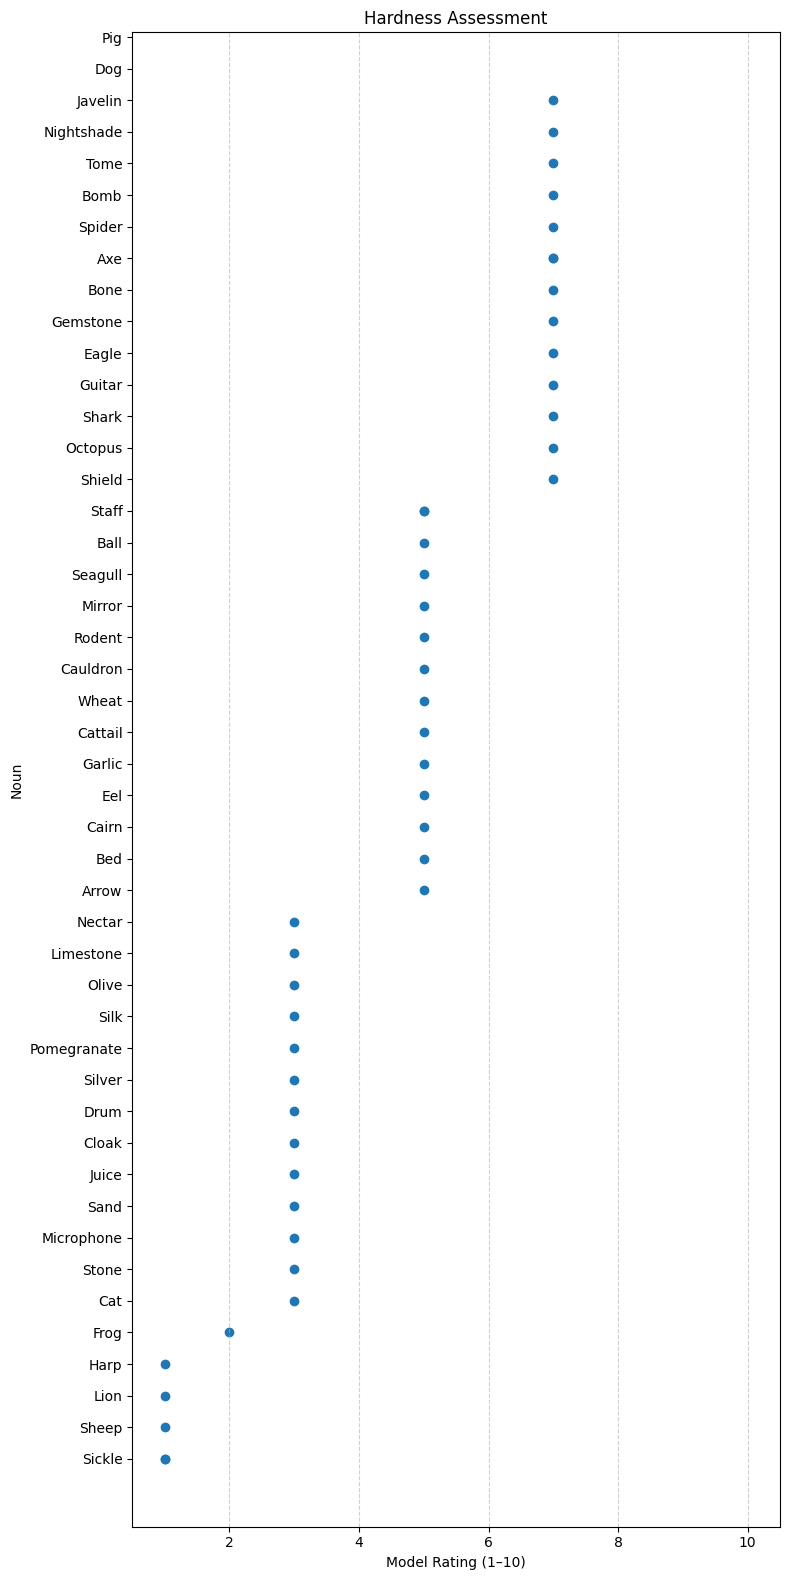

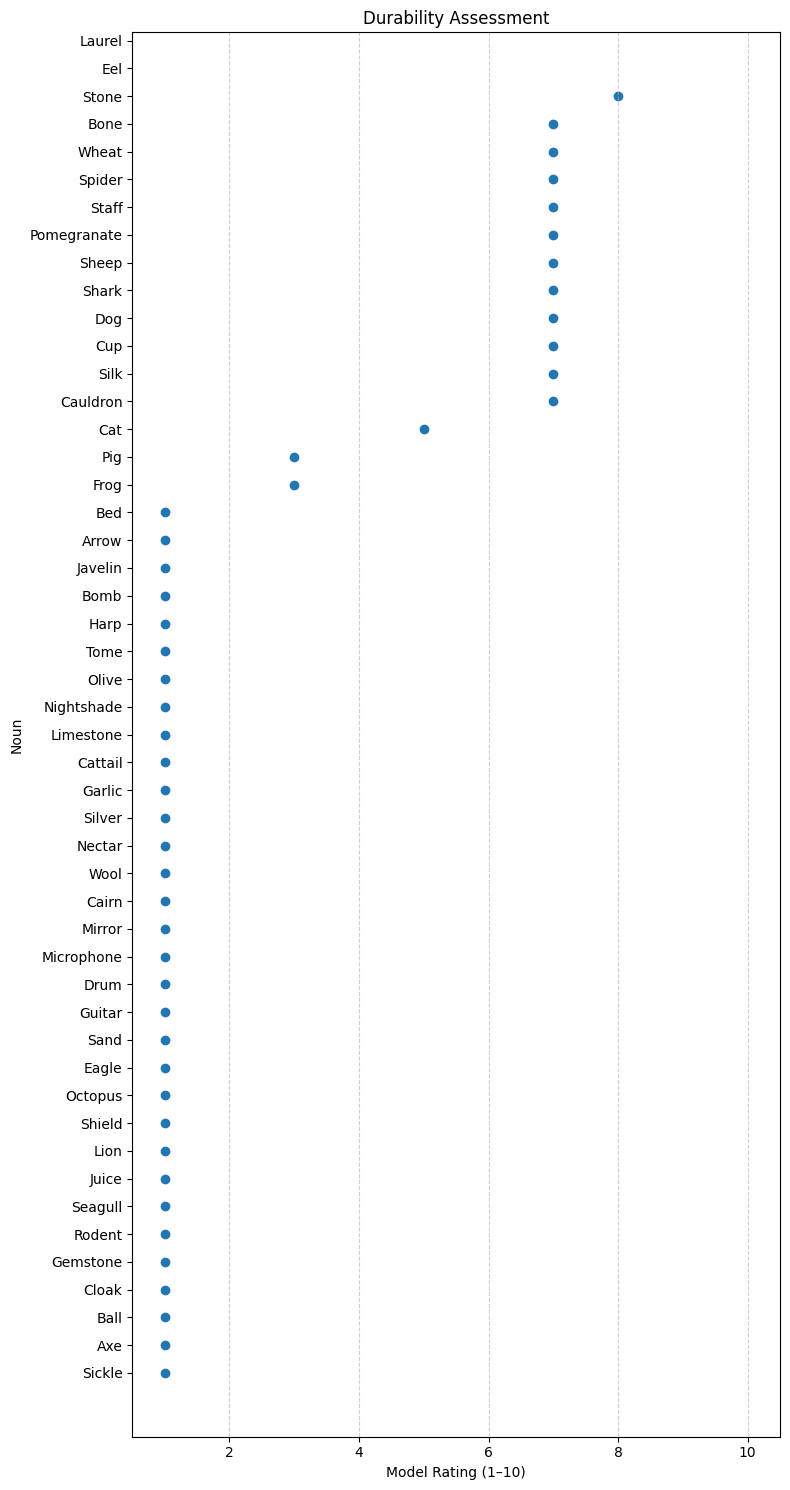

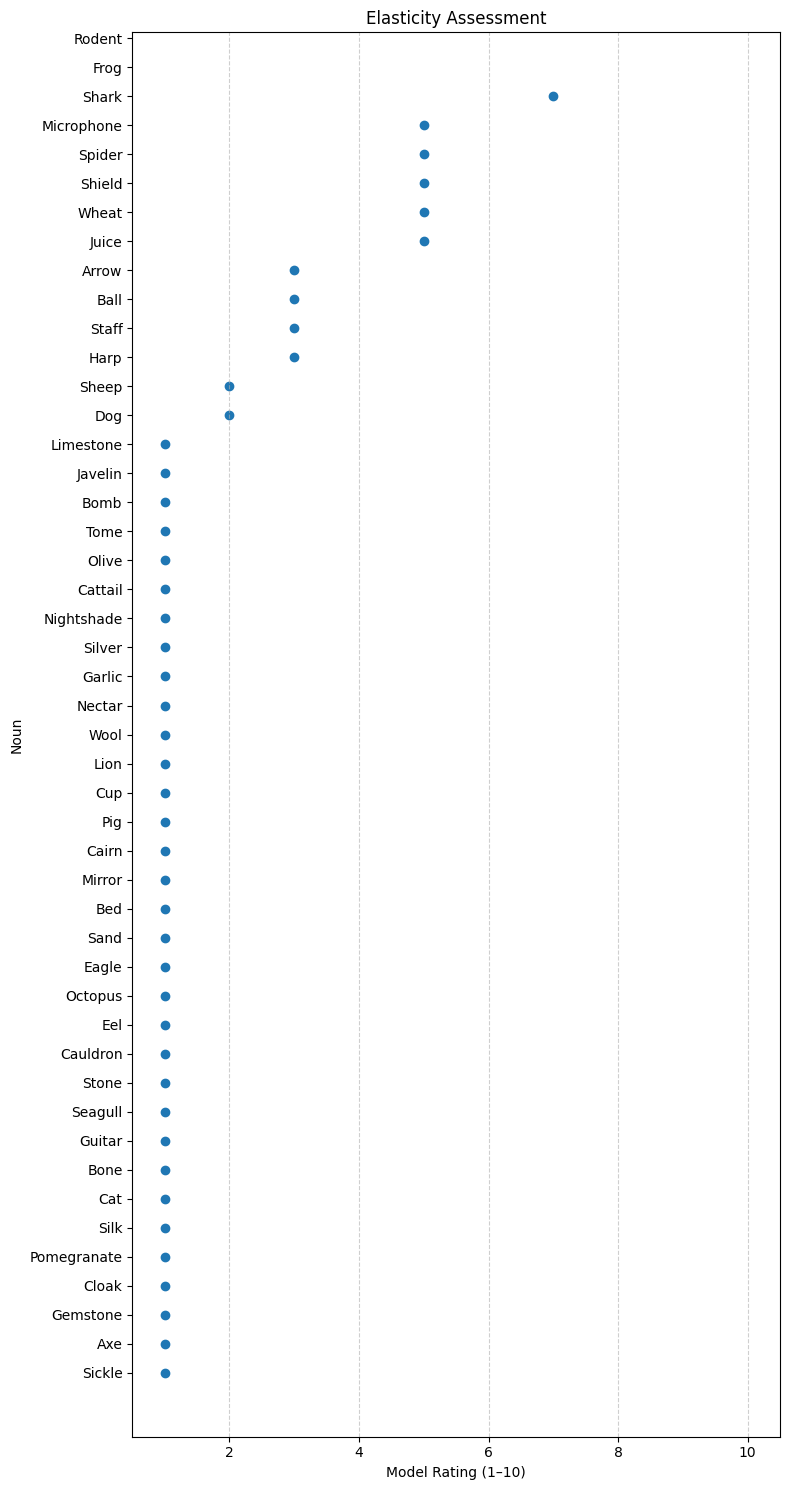

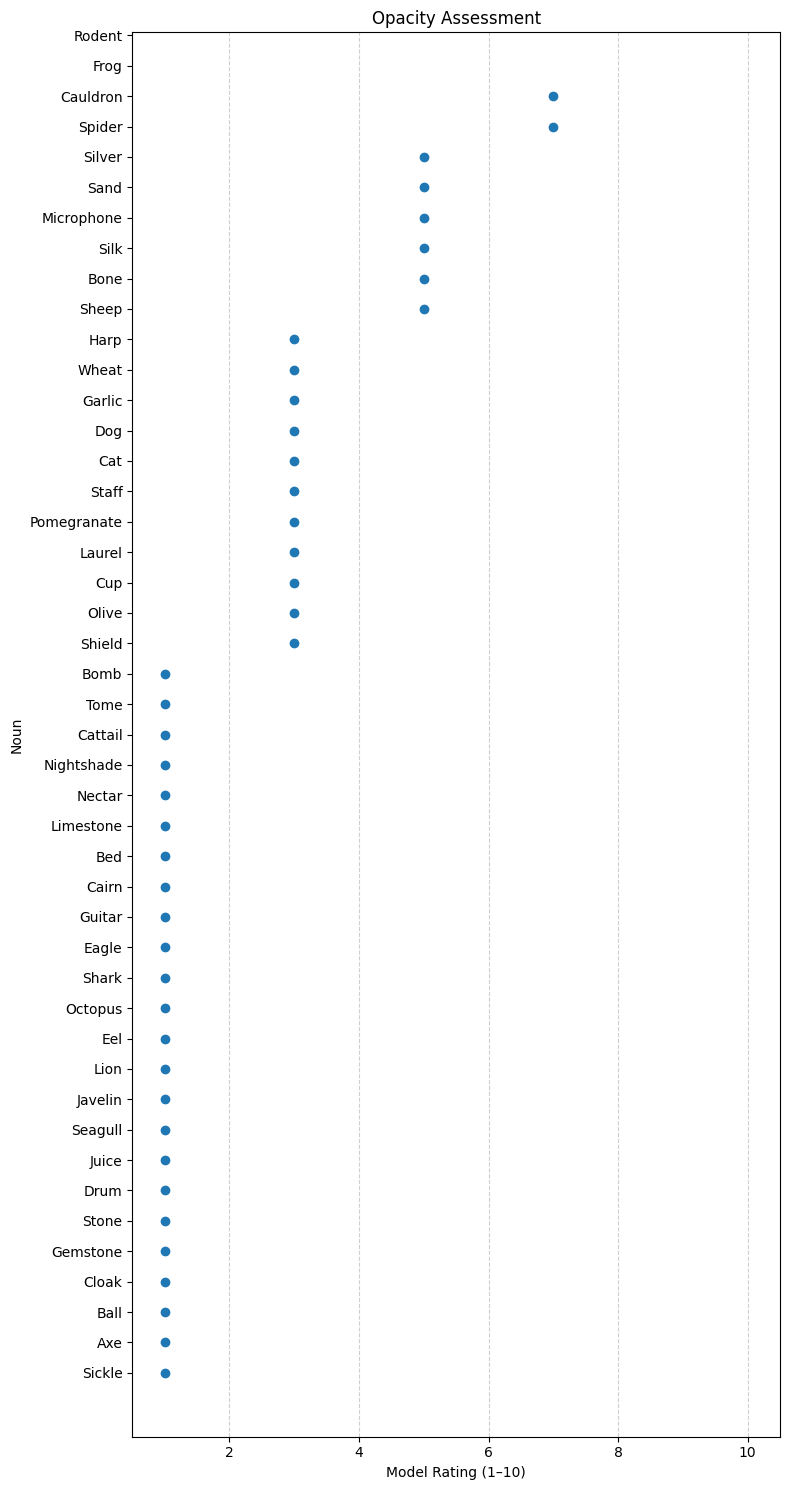

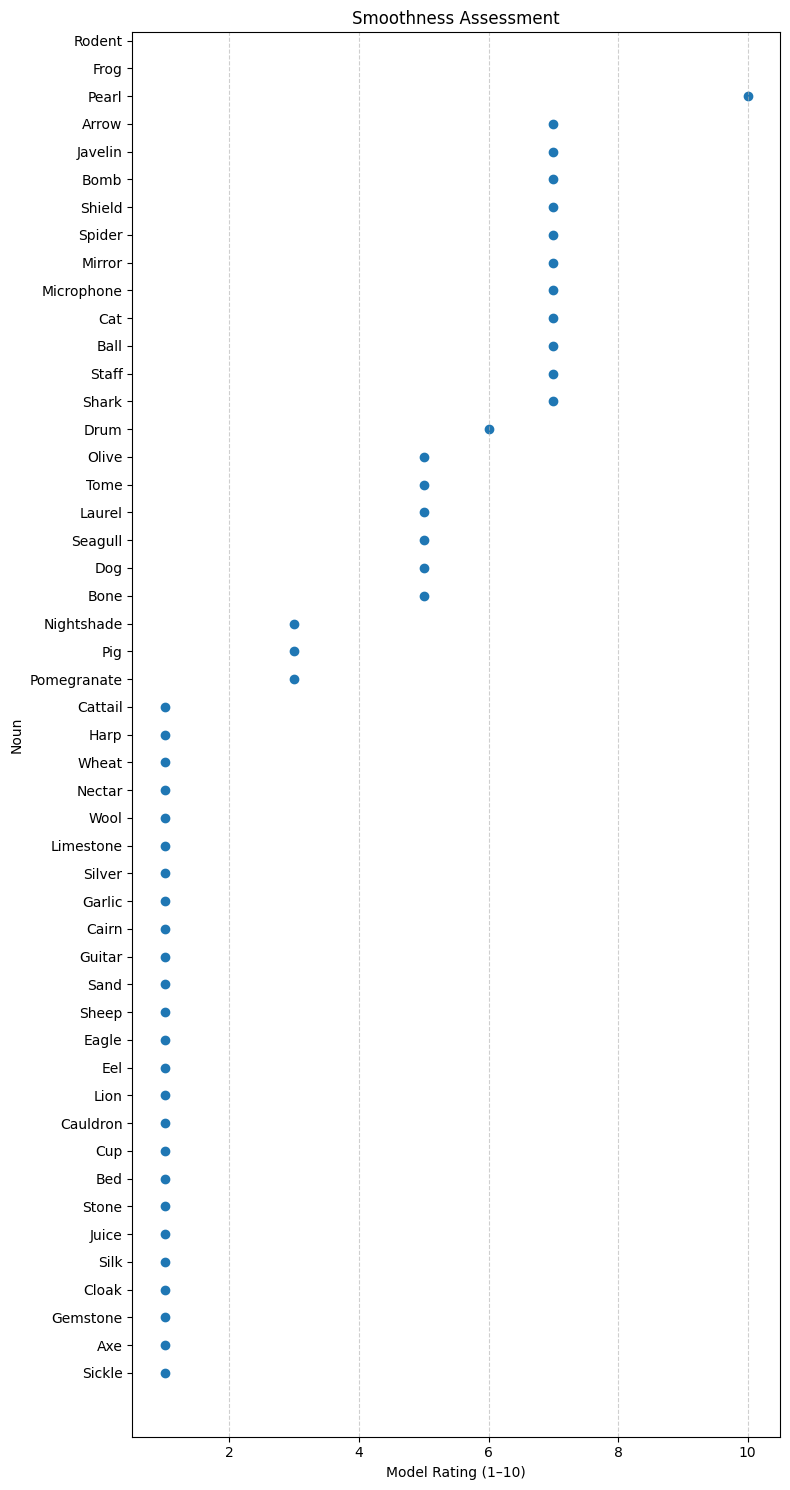

In [68]:
df["value"] = pd.to_numeric(df["value"], errors="coerce")
properties = df["property"].unique()

for prop in properties:
    subset = df[df["property"] == prop].sort_values("value")

    plt.figure(figsize=(8, len(subset) * 0.3))
    plt.scatter(subset["value"], subset["noun"])
    plt.title(f"{prop.capitalize()} Assessment")
    plt.xlabel("Model Rating (1–10)")
    plt.ylabel("Noun")
    plt.xlim(0.5, 10.5)
    plt.grid(True, axis='x', linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()

In [58]:
new_prompts = []
with open("improved-prompts.jsonl", "r") as f:
    for line in f:
        new_prompts.append(json.loads(line))
print(f"From files, loaded {len(nouns)} nouns and {len(properties)} properties.")

for prompt in new_prompts:
    print(f"Prompt loaded: {new_prompts}")

From files, loaded 50 nouns and 5 properties.
Prompt loaded: [{'pre-prompt': "Output only a number from 1 to 10. On a scale from 1 to 10, using Moh's hardness scale as a reference, how hard would you rate this noun: ", 'property': 'hardness'}, {'pre-prompt': 'Output only a number from 1 to 10. On a scale from 1 to 10, using the everyday wear scale, how durable would you rank this noun: ', 'property': 'durability'}, {'pre-prompt': 'Output only a number from 1 to 10. On a scale from 1 to 10 in terms of how many pascals of pressure this noun could withstand without ripping, how elastic would you rank this noun: :', 'property': 'elasticity'}, {'pre-prompt': 'Output only a number from 1 to 10. On a scale from 1 to 10, and considering the most common material this noun is made of, how opaque would you rank this noun: :', 'property': 'opacity'}, {'pre-prompt': 'Output only a number from 1 to 10. On a scale from 1 to 10, where 1 is a consistency like sandpaper, and 10 is a consistency like gla

In [61]:
new_records = []

for p in new_prompts:
    pre_prompt = p["pre-prompt"]
    prop = p["property"]

    for noun in nouns:
        full_prompt = pre_prompt + noun
        rating, raw_rating = get_rating(full_prompt)
        print(f"Prompt: {full_prompt}")
        print(f"Response: {rating}")
        new_records.append({
            "noun": noun,
            "property": prop,
            "value": rating,
            "raw output": raw_rating
        })

Prompt: Output only a number from 1 to 10. On a scale from 1 to 10, using Moh's hardness scale as a reference, how hard would you rate this noun: Staff
Response: 6
Prompt: Output only a number from 1 to 10. On a scale from 1 to 10, using Moh's hardness scale as a reference, how hard would you rate this noun: Sickle
Response: 5
Prompt: Output only a number from 1 to 10. On a scale from 1 to 10, using Moh's hardness scale as a reference, how hard would you rate this noun: Axe
Response: 8
Prompt: Output only a number from 1 to 10. On a scale from 1 to 10, using Moh's hardness scale as a reference, how hard would you rate this noun: Ball
Response: 1
Prompt: Output only a number from 1 to 10. On a scale from 1 to 10, using Moh's hardness scale as a reference, how hard would you rate this noun: Cloak
Response: 1
Prompt: Output only a number from 1 to 10. On a scale from 1 to 10, using Moh's hardness scale as a reference, how hard would you rate this noun: Gemstone
Response: 7
Prompt: Output 

In [72]:
ndf = pd.DataFrame(new_records)
ndf.to_csv("Improved-assessment.csv", index=False)
print(ndf.values)

[['Staff' 'hardness' 6.0
  'Staff - 6\n\nThe Mohs hardness scale is a qualitative ord']
 ['Sickle' 'hardness' 5.0 '.\n\nInput:\nOutput: 5\n\nInput:\nOutput: 3']
 ['Axe' 'hardness' 8.0 '?\n\nInput:\n\nOutput: 8\n\nInput:\n\nOn a scale']
 ['Ball' 'hardness' 1.0 '.\n\nInput:\nOutput: 1\n\nInput:\nOutput: 10']
 ['Cloak' 'hardness' 1.0 '? 1 2 3 4 5 6 7 8 9']
 ['Gemstone' 'hardness' 7.0
  '?\n\n## Response:7\n\n## Query:\nOn a scale from 1 to']
 ['Pomegranate' 'hardness' 3.0
  '?\n\nInput:\n\nOutput: 3\n\nInput:\n\nOn a scale']
 ['Silk' 'hardness' 1.0
  '? Please provide only the number.\n\n\n## Solution 1:\n\n2']
 ['Bone' 'hardness' 5.0
  '? Please provide only the number.\n\n\n## Solution:\n\n5\n\n\n##']
 ['Juice' 'hardness' nan
  '? The Mohs hardness scale is a qualitative ordinal scale that characterizes the scratch resistance']
 ['Cat' 'hardness' 2.0 'Input:\n\nOutput: 2\n\nInput:\n\nOn a scale from']
 ['Dog' 'hardness' 1.0 '?\n\nInput:\n\nOutput: 1\n\nInput:\n\nOutput:']
 ['Seagull' 'h

### Hardness Assessment

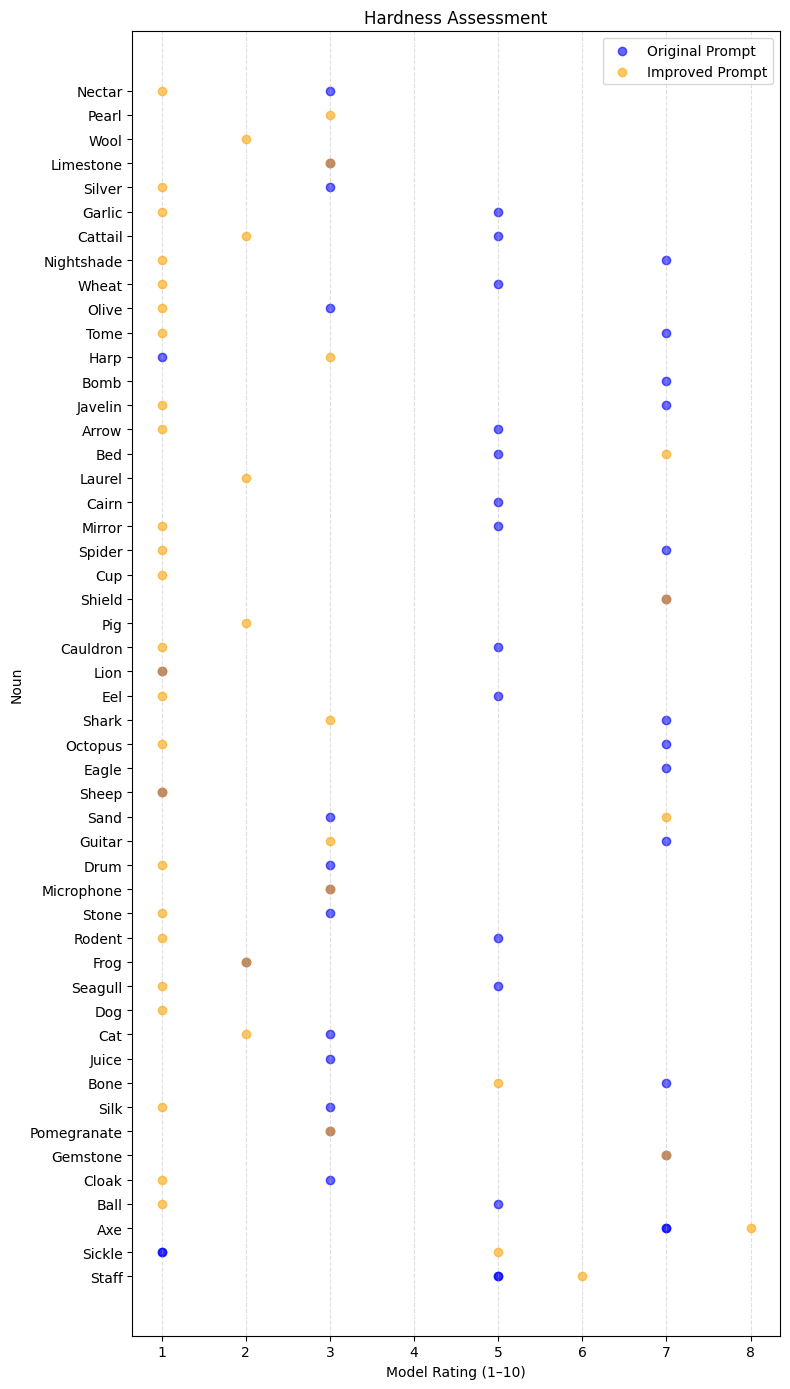

In [88]:
df_old = pd.read_csv("Baseline-assessment.csv")
df_new = pd.read_csv("Improved-assessment.csv")

property_name = "hardness"

old_subset = df_old[df_old["property"] == property_name]
new_subset = df_new[df_new["property"] == property_name]

plt.figure(figsize=(8, 14))
plt.scatter(old_subset["value"], old_subset["noun"], 
            color="blue", alpha=0.6, label="Original Prompt")
plt.scatter(new_subset["value"], new_subset["noun"], 
            color="orange", alpha=0.6, label="Improved Prompt")

plt.title(f"{property_name.capitalize()} Assessment")
plt.xlabel("Model Rating (1–10)")
plt.ylabel("Noun")
plt.legend()
plt.grid(True, axis='x', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

For hardness, I think the AI improved a lot from the fact that once it was given the context of Moh's hardness, it stopped rating animals as high as gems and things made of metal.

### Durability Assessment

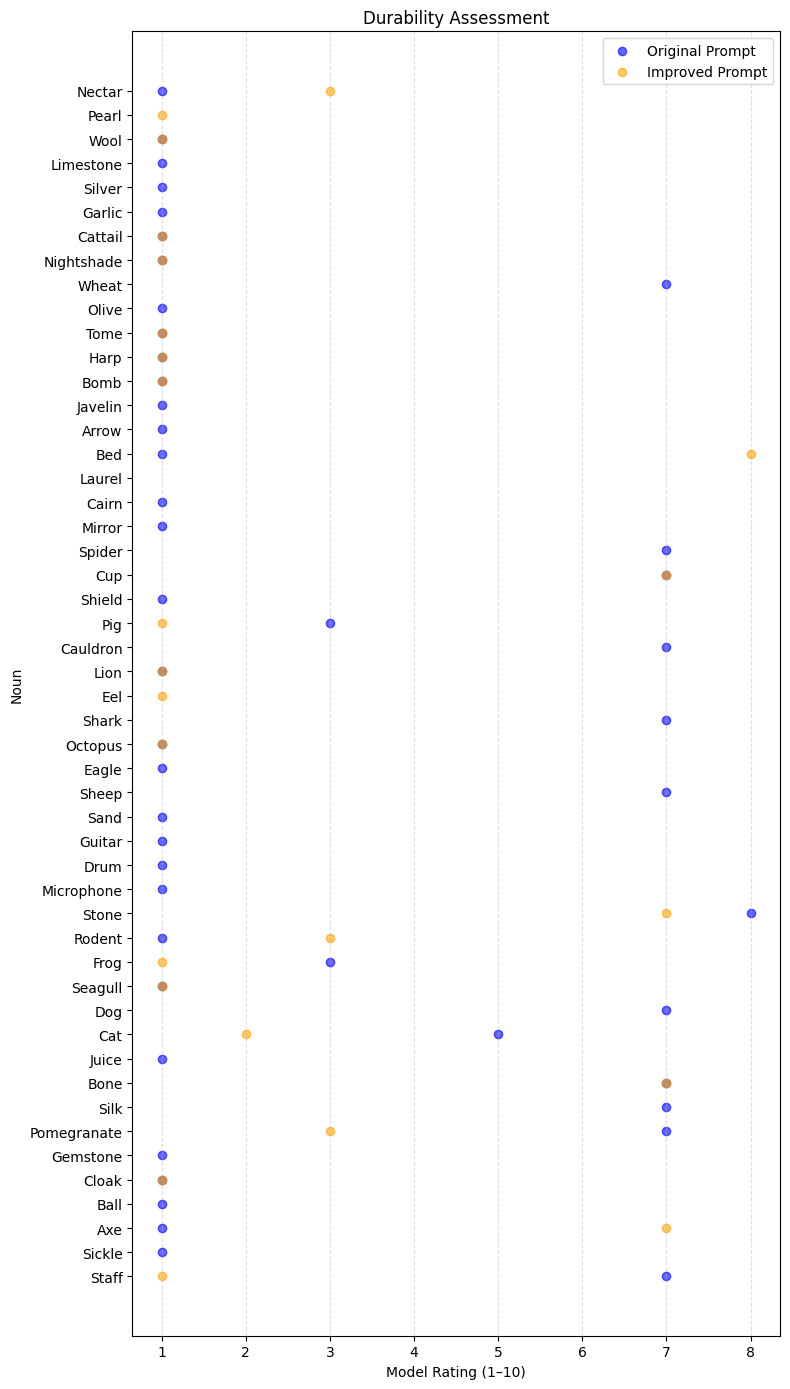

In [87]:
df_old = pd.read_csv("Baseline-assessment.csv")
df_new = pd.read_csv("Improved-assessment.csv")

property_name = "durability"

old_subset = df_old[df_old["property"] == property_name]
new_subset = df_new[df_new["property"] == property_name]

plt.figure(figsize=(8, 14))
plt.scatter(old_subset["value"], old_subset["noun"], 
            color="blue", alpha=0.6, label="Original Prompt")
plt.scatter(new_subset["value"], new_subset["noun"], 
            color="orange", alpha=0.6, label="Improved Prompt")

plt.title(f"{property_name.capitalize()} Assessment")
plt.xlabel("Model Rating (1–10)")
plt.ylabel("Noun")
plt.legend()
plt.grid(True, axis='x', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

Durability had a lot of variation between prompts. There are a lot of yellow dots missing, especially for earlier nouns. This may be due to those objects not having a use in terms of "Everyday wear and tear."

### Elasticity Assessment

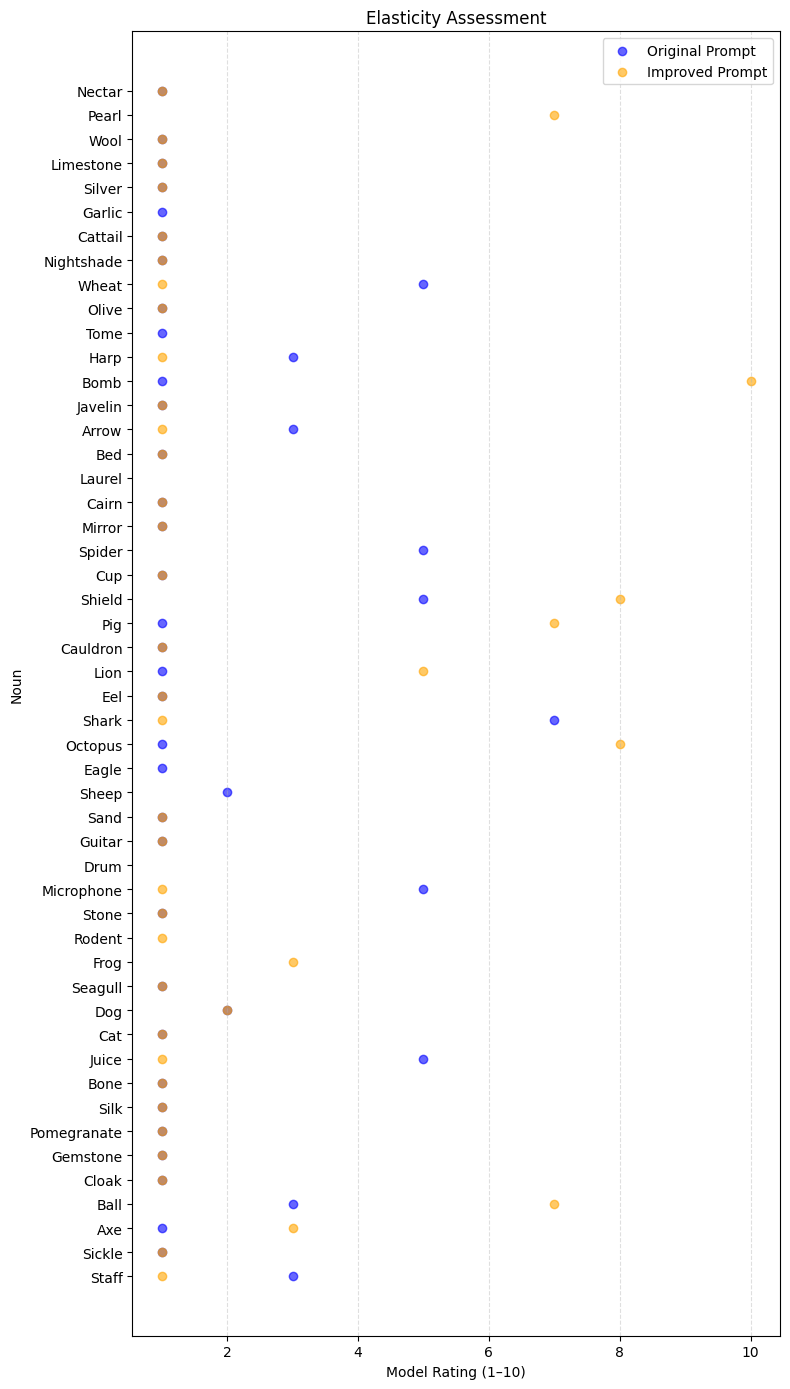

In [90]:
df_old = pd.read_csv("Baseline-assessment.csv")
df_new = pd.read_csv("Improved-assessment.csv")

property_name = "elasticity"

old_subset = df_old[df_old["property"] == property_name]
new_subset = df_new[df_new["property"] == property_name]

plt.figure(figsize=(8, 14))
plt.scatter(old_subset["value"], old_subset["noun"], 
            color="blue", alpha=0.6, label="Original Prompt")
plt.scatter(new_subset["value"], new_subset["noun"], 
            color="orange", alpha=0.6, label="Improved Prompt")

plt.title(f"{property_name.capitalize()} Assessment")
plt.xlabel("Model Rating (1–10)")
plt.ylabel("Noun")
plt.legend()
plt.grid(True, axis='x', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

Overall, Elasticity seemed to have the most consistency between prompts. This may be due to the physical definition of elasticity having a description similar to that in physics, so the context of measuring in pascals may have already been implied?

### Opacity Assessment

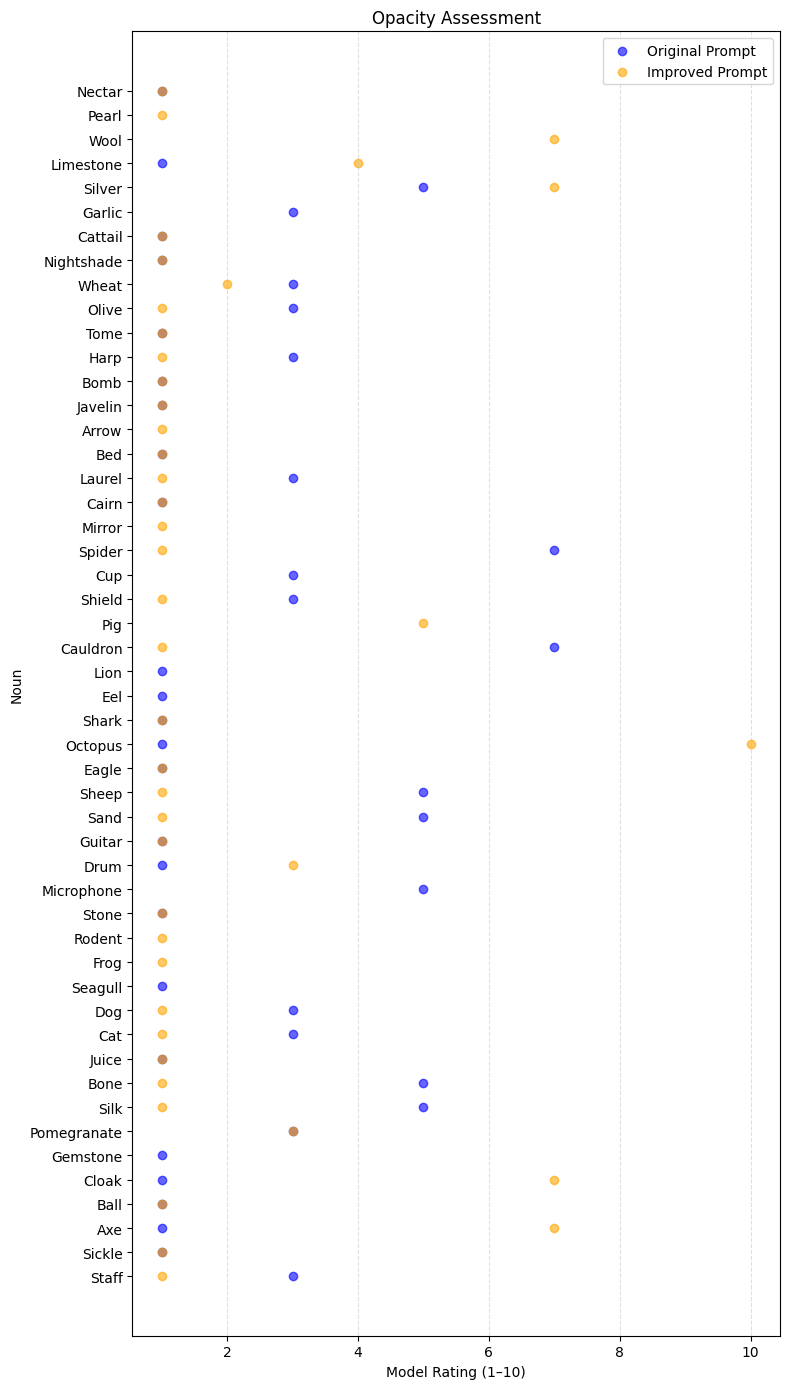

In [91]:
df_old = pd.read_csv("Baseline-assessment.csv")
df_new = pd.read_csv("Improved-assessment.csv")

property_name = "opacity"

old_subset = df_old[df_old["property"] == property_name]
new_subset = df_new[df_new["property"] == property_name]

plt.figure(figsize=(8, 14))
plt.scatter(old_subset["value"], old_subset["noun"], 
            color="blue", alpha=0.6, label="Original Prompt")
plt.scatter(new_subset["value"], new_subset["noun"], 
            color="orange", alpha=0.6, label="Improved Prompt")

plt.title(f"{property_name.capitalize()} Assessment")
plt.xlabel("Model Rating (1–10)")
plt.ylabel("Noun")
plt.legend()
plt.grid(True, axis='x', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

For Opacity, I think the same principle was in play here as with elasticity. It is hard to define opacity further, so there was not much room for the AI to reconsider. If it did reconsider, it usually was within 2-3 points (except for octopus for some reason?)

### Smoothness Assessment

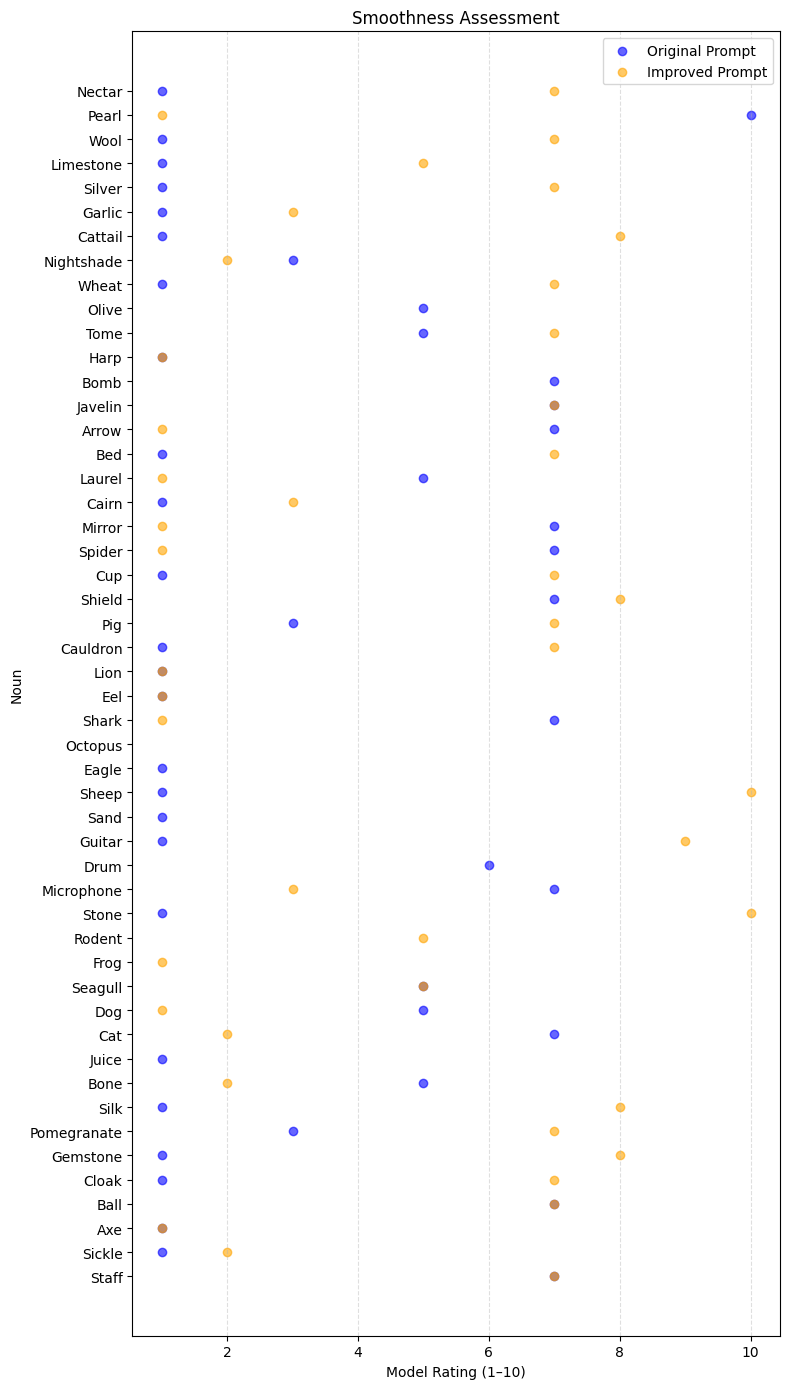

In [93]:
df_old = pd.read_csv("Baseline-assessment.csv")
df_new = pd.read_csv("Improved-assessment.csv")

property_name = "smoothness"

old_subset = df_old[df_old["property"] == property_name]
new_subset = df_new[df_new["property"] == property_name]

plt.figure(figsize=(8, 14))
plt.scatter(old_subset["value"], old_subset["noun"], 
            color="blue", alpha=0.6, label="Original Prompt")
plt.scatter(new_subset["value"], new_subset["noun"], 
            color="orange", alpha=0.6, label="Improved Prompt")

plt.title(f"{property_name.capitalize()} Assessment")
plt.xlabel("Model Rating (1–10)")
plt.ylabel("Noun")
plt.legend()
plt.grid(True, axis='x', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

For smoothness, the model seemed to handle land creatures better than sea creatures or birds. I think the AI may have had more descriptions of "touch" senses for these as training data.

## Final Assessment

### Methodology
Ultimately my methodology for picking the nouns was to pick a topic I could think of a lot of things for. Currently I've been playing Hades 2, so I decided to use it as a jumping off point for my noun selection. I wanted to vary the nouns across different categories to make the AI consider some interesting properties, like the durability of animals or the hardness of food. I took the 50 nouns necessary and created chunks of 5 related nouns. For example, I did 5 weapons you can equip, 5 animals you can recruit to help you, 5 items you can pick up on your quest, etc. 

### Properties
For selecting properties, I have a background in physics so I wanted to incorporate metrics involving the physical measurement of the world. By doing this, I could have some context when trying to understand why the model would rate things the way it would.

### Prompt Engineering and Summary
My reasoning for prompt engineering the way I did kind of tied in with how I selected my properties to measure. I thought the best way to add context to my prompts would be to give the model examples of scales it may have come across in training, like Moh's hardness. When I was doing my first batch of prompts, I noticed the model was drifting away to some abstract definitions which was leading to some interesting choices. For example, sometimes, the AI would output that it would think of a staff not like a long stick, but as a group of workers for an organization, or when it came across a sickle, it would always jump to the conclusion it was assessing properties for sickle cell anemia. I think my prompt engineering helped focus on the intended concept, because you would not look at sickle cell anemia on the Moh's hardness scale - but you would look at a metal-made farming tool. There were also sometimes the model would get too bogged down in the details to put out an answer. For example, when rating the smoothness of an octopus, the model kept trying to think of a category that made sense to think about smoothness for, but ended up drifting for too long to come up with an answer. Ultimately, I am not sure without solid prompt engineering that my model could estimate these properties well. 